# STAT 207 Homework 5 [25 points]

## Hypothesis Testing

Due: Thursday, October 3, end of day (11:59 pm CT)

<hr>

## Imports 

Run the following code cell to import the necessary packages into the file.  You may import additional packages, as needed for this assignment.

In [601]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import statsmodels.formula.api as smf

## Case Study: Colleges and Universities

We will use a random sample of post-secondary education facilities (colleges & universities) from the United States, including Puerto Rico & other US territories.  The **colleges.csv** file contains a random sample of 135 post-secondary education facilities from the US.  This data originally were obtained from: https://www.kaggle.com/yamqwe/colleges-and-universitiese
although the specific data is no longer available through this link.

We will focus on a few variables in particular:

- the categorization of the school (`NAICS_DESC`)
- the total number of students enrolled (`TOT_ENROLL`)

## 1. Read and prepare the data [1 point] 

**a)** You should read in the data from the **colleges.csv** file.

In [602]:
df = pd.read_csv('colleges.csv')
df

,Unnamed: 0,X,Y,FID,IPEDSID,NAME,ADDRESS,ADDRESS2,CITY,STATE,...,ALIAS,SIZE_SET,INST_SIZE,PT_ENROLL,FT_ENROLL,TOT_ENROLL,HOUSING,DORM_CAP,TOT_EMPLOY,SHELTER_ID
0,3003,-73.490213,40.759564,5268,189459,Briarcliffe College,1055 Stewart Ave,NOT AVAILABLE,Bethpage,NY,...,NOT AVAILABLE,9,2,440,1226,1666,2,0,356,NOT AVAILABLE
1,2832,-78.332293,35.501418,5097,198774,Johnston Community College,245 College Road,NOT AVAILABLE,Smithfield,NC,...,NOT AVAILABLE,3,2,2141,2075,4216,2,0,697,NOT AVAILABLE
2,3811,-101.891915,33.589284,1076,229337,Texas Tech University Health Sciences Center,3601 4th Street,NOT AVAILABLE,Lubbock,TX,...,NOT AVAILABLE,-2,2,916,3475,4391,2,0,5574,NOT AVAILABLE
3,5143,-85.196213,34.258192,4408,140988,Shorter University,315 Shorter Ave,NOT AVAILABLE,Rome,GA,...,Shorter,11,2,130,1378,1508,1,668,319,NOT AVAILABLE
4,7008,-83.892154,39.798614,2273,440138,Antioch University-System Administration,900 Dayton Street,NOT AVAILABLE,Yellow Springs,OH,...,NOT AVAILABLE,-3,-2,0,0,0,-2,0,89,NOT AVAILABLE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,1783,-119.732643,36.726017,6048,114813,Fresno Pacific University,1717 S Chestnut Ave,NOT AVAILABLE,Fresno,CA,...,NOT AVAILABLE,10,2,820,2512,3332,1,518,675,NOT AVAILABLE
131,5713,-96.165425,43.083651,4978,153250,Dordt College,498 4th Ave NE,NOT AVAILABLE,Sioux Center,IA,...,NOT AVAILABLE,11,2,56,1344,1400,1,1258,227,NOT AVAILABLE
132,1751,-110.996994,32.296733,6016,105163,ITT Technical Institute-Tucson,1455 W. River Rd,NOT AVAILABLE,Tucson,AZ,...,NOT AVAILABLE,-2,1,188,341,529,2,0,61,NOT AVAILABLE
133,3956,-84.192006,39.695052,1221,203544,Kettering College,3737 Southern Blvd,NOT AVAILABLE,Kettering,OH,...,NOT AVAILABLE,-2,1,417,564,981,1,120,103,NOT AVAILABLE


**b)** Perform any data cleaning that needs to take place.

**Hint:** For the data cleaning, we only care about the 2 variables defined above.  Consider possible values for the `TOT_ENROLL` variable in particular, and remove any colleges or universities that do not have possible, logical values recorded.

In [603]:
df_selected = df[['NAICS_DESC', 'TOT_ENROLL']]
df_selected

,NAICS_DESC,TOT_ENROLL
0,"Colleges, Universities, and Professional Schools",1666
1,Junior Colleges,4216
2,"Colleges, Universities, and Professional Schools",4391
3,"Colleges, Universities, and Professional Schools",1508
4,Educational Support Services/Closed,0
...,...,...
130,"Colleges, Universities, and Professional Schools",3332
131,"Colleges, Universities, and Professional Schools",1400
132,"Colleges, Universities, and Professional Schools",529
133,"Colleges, Universities, and Professional Schools",981


In [604]:
df_selected['TOT_ENROLL'].unique()

array([ 1666,  4216,  4391,  1508,     0,  3407,    77,    95,  2874,
         169, 12260,  3482,    67,   257,  1968,  1658, 23625,   177,
          53,   783,   235,  7406,   294,  2254,   775,   507,  3713,
         329,   312,    80,  1576,   695,    71, 40695,    62,   660,
        3118,  2016,   498,    86,  8368,  2741,   175,   276,   262,
         155,  9573,  4702,   142,   102, 18176,   296,   253,  8775,
         408,   918,   153, 28127,   795,  1153,   244,   371,   186,
        1894,  1107, 10979,   290,  2158,  3693, 13414,  7026,   820,
         106,   205,    22, 21557, 12228,   100,   203,   394,   644,
         640,  3359,   267,   629,  2632,  4149,  1754,  1370,    15,
        1026,   134,    25,   178,    16,    11, 16650,   128,   327,
         546,  1378,   190,   319,  5867,  1116,    96,   464,   605,
         400,   200,   453,  4509,  1148,  8140,   245,    30,   447,
        1973, 11431,    87,    12,  3332,  1400,   529,   981, 10073])

In [605]:
df_clean = df_selected[df_selected['TOT_ENROLL'] > 0]
df_clean

,NAICS_DESC,TOT_ENROLL
0,"Colleges, Universities, and Professional Schools",1666
1,Junior Colleges,4216
2,"Colleges, Universities, and Professional Schools",4391
3,"Colleges, Universities, and Professional Schools",1508
5,"Colleges, Universities, and Professional Schools",3407
...,...,...
130,"Colleges, Universities, and Professional Schools",3332
131,"Colleges, Universities, and Professional Schools",1400
132,"Colleges, Universities, and Professional Schools",529
133,"Colleges, Universities, and Professional Schools",981


In [606]:
df_clean['TOT_ENROLL'].unique()

array([ 1666,  4216,  4391,  1508,  3407,    77,    95,  2874,   169,
       12260,  3482,    67,   257,  1968,  1658, 23625,   177,    53,
         783,   235,  7406,   294,  2254,   775,   507,  3713,   329,
         312,    80,  1576,   695,    71, 40695,    62,   660,  3118,
        2016,   498,    86,  8368,  2741,   175,   276,   262,   155,
        9573,  4702,   142,   102, 18176,   296,   253,  8775,   408,
         918,   153, 28127,   795,  1153,   244,   371,   186,  1894,
        1107, 10979,   290,  2158,  3693, 13414,  7026,   820,   106,
         205,    22, 21557, 12228,   100,   203,   394,   644,   640,
        3359,   267,   629,  2632,  4149,  1754,  1370,    15,  1026,
         134,    25,   178,    16,    11, 16650,   128,   327,   546,
        1378,   190,   319,  5867,  1116,    96,   464,   605,   400,
         200,   453,  4509,  1148,  8140,   245,    30,   447,  1973,
       11431,    87,    12,  3332,  1400,   529,   981, 10073])

**c)** We are interested in making statements about junior colleges, colleges, universities, and professional schools.  Update our data so that this can be accomplished.

In [607]:
df_clean_filtered = df_clean[(df_clean['NAICS_DESC'] == 'Junior Colleges') | (df_clean['NAICS_DESC'] == 'Colleges, Universities, and Professional Schools')]
df_clean_filtered
df2 = df_clean_filtered
df2

,NAICS_DESC,TOT_ENROLL
0,"Colleges, Universities, and Professional Schools",1666
1,Junior Colleges,4216
2,"Colleges, Universities, and Professional Schools",4391
3,"Colleges, Universities, and Professional Schools",1508
5,"Colleges, Universities, and Professional Schools",3407
...,...,...
130,"Colleges, Universities, and Professional Schools",3332
131,"Colleges, Universities, and Professional Schools",1400
132,"Colleges, Universities, and Professional Schools",529
133,"Colleges, Universities, and Professional Schools",981


## 2. Typical enrollment? [1.5 points]

Although the University of Illinois is a large university with a large enrollment, there are also many smaller colleges in the state, including Parkland College with a total enrollment of 6,014.  

Since we know that there are many more smaller colleges than large universities, we'd like to test if the median college enrollment in the United States is smaller than the enrollment of Parkland College (6,014).  

We'd like to perform a hypothesis test using a 10% significance level based on our sample of colleges and universities.

**a)** Update our data to reflect the null hypothesis.

In [608]:
df2['Skeptic_Theory'] = df2['TOT_ENROLL'] - df2['TOT_ENROLL'].median() + 6014
df2

/var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/ipykernel_18504/2820965734.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Skeptic_Theory'] = df2['TOT_ENROLL'] - df2['TOT_ENROLL'].median() + 6014


,NAICS_DESC,TOT_ENROLL,Skeptic_Theory
0,"Colleges, Universities, and Professional Schools",1666,6138.0
1,Junior Colleges,4216,8688.0
2,"Colleges, Universities, and Professional Schools",4391,8863.0
3,"Colleges, Universities, and Professional Schools",1508,5980.0
5,"Colleges, Universities, and Professional Schools",3407,7879.0
...,...,...,...
130,"Colleges, Universities, and Professional Schools",3332,7804.0
131,"Colleges, Universities, and Professional Schools",1400,5872.0
132,"Colleges, Universities, and Professional Schools",529,5001.0
133,"Colleges, Universities, and Professional Schools",981,5453.0


**b)** We will use our simulation-based procedures that we have developed so far this semester.

While we only have our one sample available, we will use it as a stand in for the population.  From our sample, gather a random sample with replacement of the same size as our original sample data.  We will then repeat this process to generate many random samples.  For each of our random samples, calculate and record our statistic of interest.  We will repeat this process 5000 times, and use the 5000 observations of our statistic of interest as a sampling distribution.

array([[<Axes: title={'center': 'Skeptic_Theory_Enrollment'}>]],
      dtype=object)

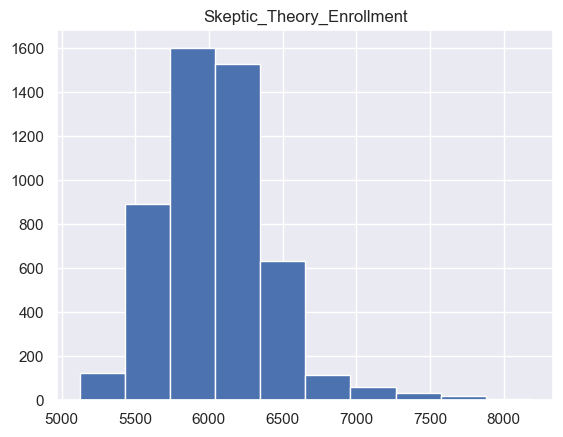

In [609]:
medians = []
for i in range(5000):
    sample = df2['Skeptic_Theory'].sample(86, replace=True)
    medians.append(sample.median())
sampling_distribution = pd.DataFrame(medians, columns=['Skeptic_Theory_Enrollment'])
sampling_distribution.hist()

In [610]:
sampling_distribution.describe()

,Skeptic_Theory_Enrollment
count,5000.00000
mean,6039.27810
std,369.88484
min,5124.00000
25%,5846.00000
50%,6014.00000
75%,6182.00000
max,8185.00000


In [611]:
p_value = (sampling_distribution['Skeptic_Theory_Enrollment'] < 6014).mean()
p_value

0.486

## Case Study: Kitchen Prep Time

The `food_prep.csv` file contains information about how much time a sample of American adults spent preparing food and drink (in minutes) in the last 24 hours.  The data has already been cleaned, so you don't need to worry about cleaning the data before analyzing it.

## 3. A Confidence Interval [1 point]

Read in the `food_prep.csv` file.  Then, generate a sampling distribution for the **median** time spent preparing food and drink by all American adults.  Finally, find the 95% confidence interval using your sampling distribution.

In [612]:
dff = pd.read_csv('food_prep.csv')
dff

,food_prep
0,15
1,2
2,60
3,45
4,0
...,...
395,60
396,0
397,0
398,0


In [613]:
dff.shape

(400, 1)

In [614]:
sampling_dist_food_prep = []

for i in range(10000):
    sample = dff['food_prep'].sample(400, replace=True)
    sampling_dist_food_prep.append(sample.median())

sampling_dist_food_prep = pd.DataFrame({'median_time': sampling_dist_food_prep})
dff2 = sampling_dist_food_prep

array([[<Axes: title={'center': 'median_time'}>]], dtype=object)

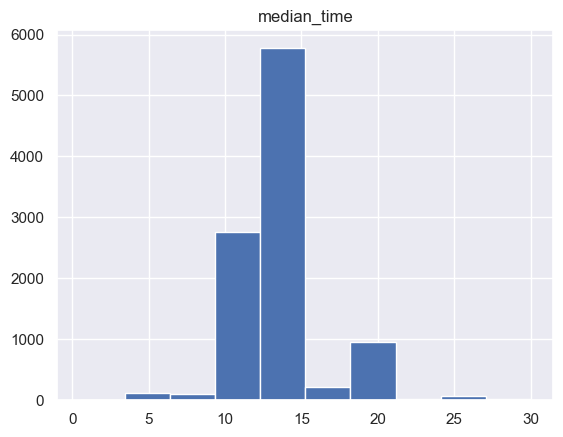

In [615]:
dff2.hist()

In [616]:
dff2.describe()

,median_time
count,10000.000000
mean,13.947350
std,3.341559
min,0.500000
25%,10.000000
50%,15.000000
75%,15.000000
max,30.000000


In [617]:
lower_bound = sampling_dist_food_prep['median_time'].quantile(0.025)
lower_bound

9.5

In [618]:
upper_bound = sampling_dist_food_prep['median_time'].quantile(0.975)
upper_bound

20.0

In [619]:
dff.describe()

,food_prep
count,400.000000
mean,31.420000
std,44.583324
min,0.000000
25%,0.000000
50%,15.000000
75%,50.000000
max,320.000000


## 4. Student Midterm Survey [1 point]

Complete the student midterm survey on Canvas to earn the last point for Homework 5, posted at 1:00 pm on Friday, September 27.

Remember to keep all your cells and hit the save icon above periodically to checkpoint (save) your results on your local computer. Once you are satisified with your results restart the kernel and run all (Kernel -> Restart & Run All). **Make sure nothing has changed**. Checkpoint and exit (File -> Save and Checkpoint + File -> Close and Halt). Follow the instructions on the Homework 5 Canvas Assignment to submit your notebook to GitHub.